In [1]:
import os
os.makedirs("../../data/etf", exist_ok=True)

# [파이낸스 데이터 획득하기](https://www.youtube.com/watch?v=kOsvm1WB58Y&list=PLXziV1DL41oh0nzW9XxVapaMJ_N27C5rK&index=2)

To install yfinance, run the following in terminal:
```
$ pip install yfinance
```
    
[yfinance](https://pypi.org/project/yfinance/)

In [2]:
import yfinance as yf
stock = yf.Ticker('SPY')
data = stock.history(period='max')
data.to_csv('../../data/etf/SPY.csv')
print(data.head())

             Open   High    Low  Close   Volume  Dividends  Stock Splits
Date                                                                    
1993-01-29  26.20  26.20  26.07  26.18  1003200        0.0             0
1993-02-01  26.20  26.37  26.20  26.37   480500        0.0             0
1993-02-02  26.35  26.44  26.30  26.43   201300        0.0             0
1993-02-03  26.46  26.72  26.44  26.71   529400        0.0             0
1993-02-04  26.80  26.87  26.50  26.82   531500        0.0             0


# [판다스 함수 그래프 그리기](https://www.youtube.com/watch?v=beTYS2W-6g4&list=PLXziV1DL41oh0nzW9XxVapaMJ_N27C5rK)

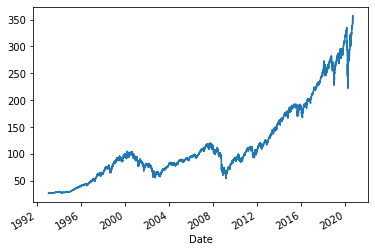

In [3]:
data['Close'].plot()

# [블록 불러오기](https://youtu.be/EYsU-CcXodM)

In [4]:
import numpy as np
data.iloc[1:,0:2+1] = np.nan
data.iloc[1:,4:] = np.nan
data.to_csv('../../data/etf/SPY_with_na_added.csv')
print(data.head())

            Open  High    Low  Close     Volume  Dividends  Stock Splits
Date                                                                    
1993-01-29  26.2  26.2  26.07  26.18  1003200.0        0.0           0.0
1993-02-01   NaN   NaN    NaN  26.37        NaN        NaN           NaN
1993-02-02   NaN   NaN    NaN  26.43        NaN        NaN           NaN
1993-02-03   NaN   NaN    NaN  26.71        NaN        NaN           NaN
1993-02-04   NaN   NaN    NaN  26.82        NaN        NaN           NaN


# CSV 파일 불러오기

In [7]:
import pandas as pd
df = pd.read_csv('../../data/etf/SPY_with_na_added.csv', 
                 index_col='Date', 
                 parse_dates=True)
print(df.head())
print(df.shape)

            Open  High    Low  Close     Volume  Dividends  Stock Splits
Date                                                                    
1993-01-29  26.2  26.2  26.07  26.18  1003200.0        0.0           0.0
1993-02-01   NaN   NaN    NaN  26.37        NaN        NaN           NaN
1993-02-02   NaN   NaN    NaN  26.43        NaN        NaN           NaN
1993-02-03   NaN   NaN    NaN  26.71        NaN        NaN           NaN
1993-02-04   NaN   NaN    NaN  26.82        NaN        NaN           NaN
(6952, 7)


# slicing keeps dim

In [8]:
x1 = df.iloc[2:5, 2:5]
print(x1)
print(x1.shape)

            Low  Close  Volume
Date                          
1993-02-02  NaN  26.43     NaN
1993-02-03  NaN  26.71     NaN
1993-02-04  NaN  26.82     NaN
(3, 3)


In [10]:
x2 = df.iloc[2:5]
#x2 = df.iloc[2:5, :]
print(x2)
print(x2.shape)

            Open  High  Low  Close  Volume  Dividends  Stock Splits
Date                                                               
1993-02-02   NaN   NaN  NaN  26.43     NaN        NaN           NaN
1993-02-03   NaN   NaN  NaN  26.71     NaN        NaN           NaN
1993-02-04   NaN   NaN  NaN  26.82     NaN        NaN           NaN
(3, 7)


In [11]:
x3 = df.iloc[:, 2:5]
print(x3)
print(x3.shape)

              Low   Close     Volume
Date                                
1993-01-29  26.07   26.18  1003200.0
1993-02-01    NaN   26.37        NaN
1993-02-02    NaN   26.43        NaN
1993-02-03    NaN   26.71        NaN
1993-02-04    NaN   26.82        NaN
...           ...     ...        ...
2020-08-31    NaN  349.31        NaN
2020-09-01    NaN  352.60        NaN
2020-09-02    NaN  357.70        NaN
2020-09-03    NaN  345.39        NaN
2020-09-04    NaN  342.35        NaN

[6952 rows x 3 columns]
(6952, 3)


# indexing reduces dim

In [13]:
x5 = df.iloc[2, 5]
print(x5)
print("x5.shape : {}".format(x5.shape)) 
print('x5.shape이 ()이므로, x5는 판다스 데이타프레임 혹은 시리즈가 아니라 그냥 일반적인 숫자임.')
print("type(x5) : {}".format(type(x5))) 

nan
x5.shape : ()
x5.shape이 ()이므로, x5는 판다스 데이타프레임 혹은 시리즈가 아니라 그냥 일반적인 숫자임.
type(x5) : <class 'numpy.float64'>


In [14]:
x6 = df.iloc[2, :]
print(x6)
print("x6.shape : {}".format(x6.shape)) 
print('x6.shape이 (7,)이므로, x6는 판다스 데이타프레임이 아니라 시리즈임.')
print("type(x6) : {}".format(type(x6))) 

Open              NaN
High              NaN
Low               NaN
Close           26.43
Volume            NaN
Dividends         NaN
Stock Splits      NaN
Name: 1993-02-02 00:00:00, dtype: float64
x6.shape : (7,)
x6.shape이 (7,)이므로, x6는 판다스 데이타프레임이 아니라 시리즈임.
type(x6) : <class 'pandas.core.series.Series'>


In [53]:
x7 = df.iloc[:, 2]
print(x7)
print("x7.shape : {}".format(x7.shape)) 
print('x7.shape이 (6952,)이므로, x7은 판다스 데이타프레임이 아니라 시리즈임.')
print("type(x7) : {}".format(type(x7))) 

Date
1993-01-29    26.07
1993-02-01      NaN
1993-02-02      NaN
1993-02-03      NaN
1993-02-04      NaN
              ...  
2020-08-31      NaN
2020-09-01      NaN
2020-09-02      NaN
2020-09-03      NaN
2020-09-04      NaN
Name: Low, Length: 6952, dtype: float64
x7.shape : (6952,)
x7.shape이 (6952,)이므로, x7은 판다스 데이타프레임이 아니라 시리즈임.
type(x7) : <class 'pandas.core.series.Series'>


# 아리송한 케이스 - 한 개의 칼럼만 불렀을 때

In [15]:
x8 = df[['Open','High','Low','Close']]
print(x8)
print(x8.shape, type(x8))

            Open  High    Low   Close
Date                                 
1993-01-29  26.2  26.2  26.07   26.18
1993-02-01   NaN   NaN    NaN   26.37
1993-02-02   NaN   NaN    NaN   26.43
1993-02-03   NaN   NaN    NaN   26.71
1993-02-04   NaN   NaN    NaN   26.82
...          ...   ...    ...     ...
2020-08-31   NaN   NaN    NaN  349.31
2020-09-01   NaN   NaN    NaN  352.60
2020-09-02   NaN   NaN    NaN  357.70
2020-09-03   NaN   NaN    NaN  345.39
2020-09-04   NaN   NaN    NaN  342.35

[6952 rows x 4 columns]
(6952, 4) <class 'pandas.core.frame.DataFrame'>


In [16]:
x9 = df[['Close']]
print(x9)
print(x9.shape, type(x9))

             Close
Date              
1993-01-29   26.18
1993-02-01   26.37
1993-02-02   26.43
1993-02-03   26.71
1993-02-04   26.82
...            ...
2020-08-31  349.31
2020-09-01  352.60
2020-09-02  357.70
2020-09-03  345.39
2020-09-04  342.35

[6952 rows x 1 columns]
(6952, 1) <class 'pandas.core.frame.DataFrame'>


In [17]:
x10 = df['Close']
print(x10)
print(x10.shape, type(x10))

Date
1993-01-29     26.18
1993-02-01     26.37
1993-02-02     26.43
1993-02-03     26.71
1993-02-04     26.82
               ...  
2020-08-31    349.31
2020-09-01    352.60
2020-09-02    357.70
2020-09-03    345.39
2020-09-04    342.35
Name: Close, Length: 6952, dtype: float64
(6952,) <class 'pandas.core.series.Series'>


In [18]:
x11 = df.Close # df.Close == df['Close']
print(x11)
print(x11.shape, type(x11))

Date
1993-01-29     26.18
1993-02-01     26.37
1993-02-02     26.43
1993-02-03     26.71
1993-02-04     26.82
               ...  
2020-08-31    349.31
2020-09-01    352.60
2020-09-02    357.70
2020-09-03    345.39
2020-09-04    342.35
Name: Close, Length: 6952, dtype: float64
(6952,) <class 'pandas.core.series.Series'>


# drop and dropna method keep dim

In [19]:
x12 = df.drop(['Open', 'High', 'Low', 'Volume', 'Dividends', 'Stock Splits'], axis=1)
print(x12)
print(x12.shape, type(x12))

             Close
Date              
1993-01-29   26.18
1993-02-01   26.37
1993-02-02   26.43
1993-02-03   26.71
1993-02-04   26.82
...            ...
2020-08-31  349.31
2020-09-01  352.60
2020-09-02  357.70
2020-09-03  345.39
2020-09-04  342.35

[6952 rows x 1 columns]
(6952, 1) <class 'pandas.core.frame.DataFrame'>


In [20]:
x13 = df.dropna(axis=1)
print(x13)
print(x13.shape, type(x13))

             Close
Date              
1993-01-29   26.18
1993-02-01   26.37
1993-02-02   26.43
1993-02-03   26.71
1993-02-04   26.82
...            ...
2020-08-31  349.31
2020-09-01  352.60
2020-09-02  357.70
2020-09-03  345.39
2020-09-04  342.35

[6952 rows x 1 columns]
(6952, 1) <class 'pandas.core.frame.DataFrame'>


In [21]:
x14 = df.dropna()
print(x14)
print(x14.shape, type(x14))

            Open  High    Low  Close     Volume  Dividends  Stock Splits
Date                                                                    
1993-01-29  26.2  26.2  26.07  26.18  1003200.0        0.0           0.0
(1, 7) <class 'pandas.core.frame.DataFrame'>
